In [77]:
import os
from dataclasses import dataclass
from typing import Callable, List, Optional, Dict, Any, Tuple, Literal, Union, Sequence

import pandas as pd
import matplotlib.pyplot as plt

Point = Dict[str, Any]
SelectFn = Callable[[List[Point]], List[Point]]


# -----------------------------
# Specs
# -----------------------------
@dataclass
class GroupSpec:
    label: str
    csv_paths: List[str]
    style: Dict[str, Any]

    domain: str = "in"
    epochs: Optional[List[int]] = None

    mode: Literal["points", "trajectory", "single"] = "points"
    connect: bool = False  # if True and mode="trajectory", draw per-file lines

    # selection reducer (applied per-file when mode in {"single","trajectory"}; and also in "points" if you want)
    select_fn: Optional[SelectFn] = None

    annotate: bool = False
    annotate_text_fn: Optional[Callable[[Point], str]] = None
    annotate_kwargs: Optional[Dict[str, Any]] = None

    # reference line controls
    ref_line: bool = False
    ref_line_style: Optional[Dict[str, Any]] = None
    ref_line_label: bool = False


@dataclass
class AnchorSpec:
    """
    Anchor is selected by returning a Point (NOT an index) from the group's plotted points.
    This avoids index mismatch after filtering / per-file reductions.
    """
    group_label: str
    select_fn: Callable[[List[Point]], Point]  # returns the selected anchor Point
    style: Dict[str, Any]
    annotate_text: Optional[str] = None
    annotate_kwargs: Optional[Dict[str, Any]] = None


@dataclass
class MemorySpec:
    label: str
    points: Union[Tuple[float, float], List[Tuple[float, float]]]
    style: Dict[str, Any]

    epochs: Optional[List[int]] = None

    mode: Literal["points", "trajectory", "single"] = "points"
    connect: bool = False

    ref_line: bool = False
    ref_line_style: Optional[Dict[str, Any]] = None
    ref_line_label: bool = False

    annotate_texts: Optional[List[str]] = None


# -----------------------------
# IO helpers
# -----------------------------
def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}. Available: {list(df.columns)}")

def read_mi_points(csv_path: str, domain: str, epoch_col: str = "Epoch") -> List[Point]:
    """
    Read all MI points from one CSV. Each row corresponds to one epoch.
    """
    df = pd.read_csv(csv_path)

    if domain == "in":
        ix_col = find_column(df, ["I(X;T)-In"])
        iy_col = find_column(df, ["I(T;Y)-In"])
    elif domain == "out":
        ix_col = find_column(df, ["I(X;T)-Out"])
        iy_col = find_column(df, ["I(T;Y)-Out"])
    else:
        raise ValueError("domain must be 'in' or 'out'")

    epochs = df[epoch_col].tolist() if epoch_col in df.columns else [None] * len(df)

    points: List[Point] = []
    for e, ix, iy in zip(epochs, df[ix_col], df[iy_col]):
        points.append({"path": csv_path, "epoch": e, "ix": float(ix), "iy": float(iy)})
    return points

def points_from_memoryspec(m: MemorySpec) -> List[Point]:
    pts = m.points
    if isinstance(pts, tuple) and len(pts) == 2 and isinstance(pts[0], (int, float)):
        pts = [pts]

    out: List[Point] = []
    for i, (ix, iy) in enumerate(pts):
        e = m.epochs[i] if (m.epochs is not None and i < len(m.epochs)) else None
        out.append({"path": "<memory>", "epoch": e, "ix": float(ix), "iy": float(iy)})
    return out


# -----------------------------
# Selection helpers
# -----------------------------
def select_last(points: List[Point]) -> List[Point]:
    return [points[-1]] if points else []


def select_first(points: List[Point]) -> List[Point]:
    return points[:1] if points else []


def select_epoch(e: int) -> SelectFn:
    def _sel(points: List[Point]) -> List[Point]:
        return [p for p in points if p.get("epoch", None) == e]
    return _sel


def select_best_by(key: str, maximize: bool = True) -> SelectFn:
    def _sel(points: List[Point]) -> List[Point]:
        if not points:
            return []
        return [max(points, key=lambda p: p[key])] if maximize else [min(points, key=lambda p: p[key])]
    return _sel


# -----------------------------
# Core plotting
# -----------------------------
def plot_information_plane(
    groups: Sequence[Union[GroupSpec, MemorySpec]],
    title: Optional[str] = None,
    figsize: Tuple[int, int] = (7, 6),
    grid: bool = True,
    plain_ticks: bool = True,
    anchor: Optional[AnchorSpec] = None,
    legend_outside: bool = True,
):
    """
    Final behavior:
    - GroupSpec supports multiple csv_paths robustly.
      * mode="single": one point PER FILE (after optional select_fn, else last)
      * mode="trajectory": one trajectory PER FILE (after optional select_fn; connect controls line drawing)
      * mode="points": all points from all files (optionally filtered by epochs; optional select_fn applied per-file)
    - AnchorSpec.select_fn returns an actual Point from the plotted points (no index mismatch).
    """

    # Storage:
    # - scatter_points[label] = flat list of points to scatter
    # - trajectories[label] = list of trajectories, each trajectory is list[Point] (per file)
    scatter_points: Dict[str, List[Point]] = {}
    trajectories: Dict[str, List[List[Point]]] = {}

    # -----------------------------
    # Load & prepare points
    # -----------------------------
    for g in groups:
        if isinstance(g, MemorySpec):
            pts = points_from_memoryspec(g)
            pts.sort(key=lambda x: (x["epoch"] is None, x["epoch"]))

            # single -> last point only
            if g.mode == "single" and len(pts) > 1:
                pts = pts[-1:]

            scatter_points[g.label] = pts
            trajectories[g.label] = [pts] if (g.mode == "trajectory") else []
            continue

        # ---- GroupSpec (CSV-backed) ----
        paths = g.csv_paths if isinstance(g.csv_paths, list) else [g.csv_paths]

        per_file_trajs: List[List[Point]] = []
        per_file_scatter: List[Point] = []

        for p in paths:
            pts_p = read_mi_points(p, g.domain)

            # epoch filter
            if g.epochs is not None:
                pts_p = [pt for pt in pts_p if pt["epoch"] in g.epochs]

            # sort by epoch inside each file
            pts_p.sort(key=lambda x: (x["epoch"] is None, x["epoch"]))

            # apply select_fn PER FILE (important!)
            if g.select_fn is not None:
                pts_p = g.select_fn(pts_p)

            if g.mode == "single":
                pts_p = pts_p[-1:] if pts_p else []
                per_file_scatter.extend(pts_p)

            elif g.mode == "trajectory":
                # keep each file's trajectory separately
                per_file_trajs.append(pts_p)
                per_file_scatter.extend(pts_p)

            else:  # "points"
                per_file_scatter.extend(pts_p)

        scatter_points[g.label] = per_file_scatter
        trajectories[g.label] = per_file_trajs

    # -----------------------------
    # Anchor selection (returns Point)
    # -----------------------------
    anchor_point: Optional[Point] = None
    if anchor is not None:
        if anchor.group_label not in scatter_points:
            raise ValueError(f"Anchor group '{anchor.group_label}' not found.")
        candidates = scatter_points[anchor.group_label]
        if not candidates:
            raise ValueError(f"Anchor group '{anchor.group_label}' has no points after filtering/selection.")
        anchor_point = anchor.select_fn(candidates)

        # sanity: must be one of the plotted points (match by path+epoch+coords)
        def _same(a: Point, b: Point) -> bool:
            return (
                a.get("path") == b.get("path")
                and a.get("epoch") == b.get("epoch")
                and abs(a.get("ix") - b.get("ix")) < 1e-12
                and abs(a.get("iy") - b.get("iy")) < 1e-12
            )
        if not any(_same(anchor_point, p) for p in candidates):
            raise ValueError("AnchorSpec.select_fn must return a point that exists in the group's plotted points.")

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=figsize)
    ax = plt.gca()

    legend_seen = set()

    for g in groups:
        pts = scatter_points.get(g.label, [])

        # Per-file trajectory lines
        if isinstance(g, GroupSpec) and g.mode == "trajectory" and g.connect and trajectories.get(g.label):
            # build line kwargs from scatter style
            line_kw = {}
            if "color" in g.style:
                line_kw["color"] = g.style["color"]
            if "alpha" in g.style:
                line_kw["alpha"] = g.style["alpha"]
            # optional extras
            line_kw.setdefault("linewidth", 1.2)

            for traj in trajectories[g.label]:
                if len(traj) >= 2:
                    xs = [pt["ix"] for pt in traj]
                    ys = [pt["iy"] for pt in traj]
                    ax.plot(xs, ys, **line_kw)

        # Scatter points
        for pt in pts:
            is_anchor = (
                anchor_point is not None
                and pt.get("path") == anchor_point.get("path")
                and pt.get("epoch") == anchor_point.get("epoch")
                and abs(pt["ix"] - anchor_point["ix"]) < 1e-12
                and abs(pt["iy"] - anchor_point["iy"]) < 1e-12
            )

            style = dict(g.style)
            label = "Anchor" if is_anchor else g.label

            # legend key: keep in/out separate if user uses same label accidentally by including domain
            legend_key = (label, getattr(g, "domain", None))
            label_for_scatter = None if legend_key in legend_seen else label
            legend_seen.add(legend_key)

            if is_anchor and anchor is not None:
                style.update(anchor.style)

            ax.scatter(pt["ix"], pt["iy"], label=label_for_scatter, **style)

            # Reference crosshair: draw only for "single" groups OR anchor point
            if getattr(g, "ref_line", False) and (getattr(g, "mode", None) == "single" or is_anchor):
                kw = {"linestyle": "--", "linewidth": 1.2, "alpha": 0.7}
                if getattr(g, "ref_line_style", None):
                    kw.update(g.ref_line_style)
                ax.axvline(pt["ix"], **kw)
                ax.axhline(pt["iy"], **kw)

                if getattr(g, "ref_line_label", False):
                    ax.annotate(
                        g.label,
                        (pt["ix"], pt["iy"]),
                        textcoords="offset points",
                        xytext=(6, 6),
                        fontsize=9,
                        alpha=0.9,
                    )

            # Custom annotations
            if getattr(g, "annotate", False) and getattr(g, "annotate_text_fn", None):
                text = g.annotate_text_fn(pt)
                akw = g.annotate_kwargs or {"xytext": (6, 6), "fontsize": 9, "alpha": 0.9}
                ax.annotate(text, (pt["ix"], pt["iy"]), textcoords="offset points", **akw)

            # Anchor annotation
            if is_anchor and anchor is not None and anchor.annotate_text:
                akw = anchor.annotate_kwargs or {"xytext": (8, 8), "fontsize": 9, "fontweight": "bold"}
                ax.annotate(anchor.annotate_text, (pt["ix"], pt["iy"]), textcoords="offset points", **akw)

    # -----------------------------
    # Formatting
    # -----------------------------
    ax.set_xlabel("I(X;T)")
    ax.set_ylabel("I(T;Y)")
    ax.set_title(title)

    if grid:
        ax.grid(True)

    if plain_ticks:
        ax.ticklabel_format(style="plain", axis="both", useOffset=False)

    # -----------------------------
    # Legend placement
    # -----------------------------
    if legend_outside:
        plt.subplots_adjust(right=0.78)
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
            frameon=True
        )
    else:
        ax.legend(frameon=True)

    plt.show()


# -----------------------------
# Example anchor selector (Point-based)
# -----------------------------
def anchor_by_rate_from_filename(rate: float = 1.0) -> Callable[[List[Point]], Point]:
    """
    Example: choose anchor among points whose filename token[-2] == rate.
    Works best when the group is mode="single" (one point per file), so each file contributes one candidate.
    """
    def _sel(points: List[Point]) -> Point:
        candidates: List[Point] = []
        for pt in points:
            fname = os.path.basename(pt["path"]).replace(".csv", "")
            toks = fname.split("_")
            try:
                r = float(toks[-2])
            except Exception:
                continue
            if abs(r - rate) < 1e-12:
                candidates.append(pt)

        if not candidates:
            raise ValueError(f"No points found with rate={rate} in filename token[-2].")

        # choose max iy (tie-breaker: min ix)
        return max(candidates, key=lambda p: (p["iy"], -p["ix"]))
    return _sel


In [63]:
def build_neg_dict(dataset_name, model_name, seed_range, 
                   rates=None, num_iterations=1, base_size=40000):
    
    if rates is None:
        rates = [0.0] + [round(r * 0.1, 1) for r in range(1, 11)]

    base_dir = "./saved_logs/vanilla/MI"

    neg_dict = {rate: [] for rate in rates}
    
    for _ in range(num_iterations):
        for rate in rates:
            for seed in seed_range:
                if rate == 1.0 or rate == 0.0:
                    path = (f"{base_dir}/training_log_{dataset_name}_{model_name}"
                            f"_{base_size}_{seed}_1.0_MI.csv")
                else:
                    path = (f"{base_dir}/training_log_{dataset_name}_{model_name}"
                            f"_{base_size}_{seed}_1.0_overlap_{rate}_size_10000_MI.csv")
                neg_dict[rate].append(path)

    return neg_dict

In [ ]:
neg_dict = build_neg_dict("CIFAR-10", "ResNet-18", seed_range)
print(neg_dict)

In [67]:
rate_colors = {
    0.1: "#1f77b4",  0.2: "#ff7f0e",  0.3: "#2ca02c",
    0.4: "#d62728",  0.5: "#9467bd",  0.6: "#8c564b",
    0.7: "#e377c2",  0.8: "#7f7f7f",  0.9: "#bcbd22",
    1.0: "#17becf",  0.0: "#000000",
}

def plot_neg_pairs(dataset_name, model_name, seed_range, base_size):
    neg_dict = build_neg_dict(dataset_name, model_name, seed_range, base_size=base_size)

    in_group_ls = []
    out_group_ls = []

    for key, value in neg_dict.items():
        if key != 0.0:
            spec = GroupSpec(
                label=f"Negative (In) - rate={key}",
                csv_paths=value,
                domain="in",
                style={"marker": "o", "color": rate_colors[key], "s": 70, "alpha": 0.95},
                mode="single",
                select_fn=select_last,
            )
            in_group_ls.append(spec)
        else:
            out_group_ls.append(GroupSpec(
                                label=f"Negative (Out) - rate={key}",
                                csv_paths=value,
                                domain="out",
                                style={"marker": "o", "color": rate_colors[key], "s": 70, "alpha": 0.95},
                                mode="single",
                                select_fn=select_last,
                            ))
    plot_information_plane(in_group_ls + out_group_ls, title=f"{dataset_name} {model_name} {base_size} Negative Models")

# Plot Check

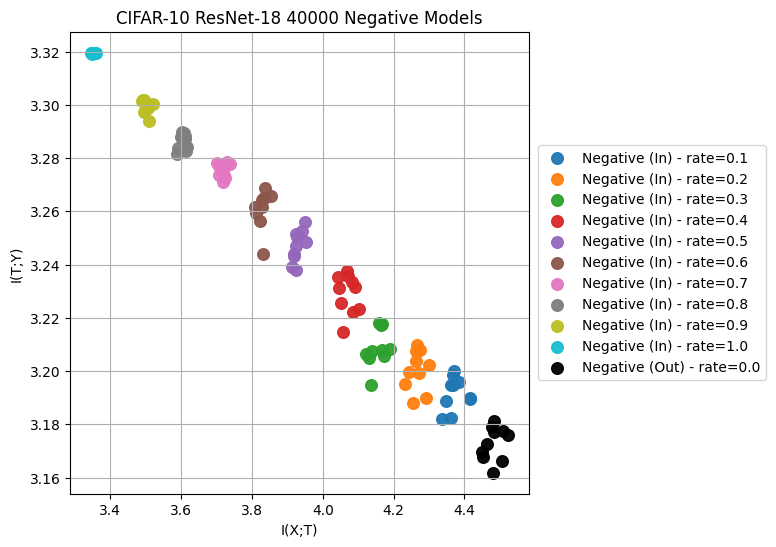

In [68]:
plot_neg_pairs("CIFAR-10", "ResNet-18", range(42, 52), 40000)

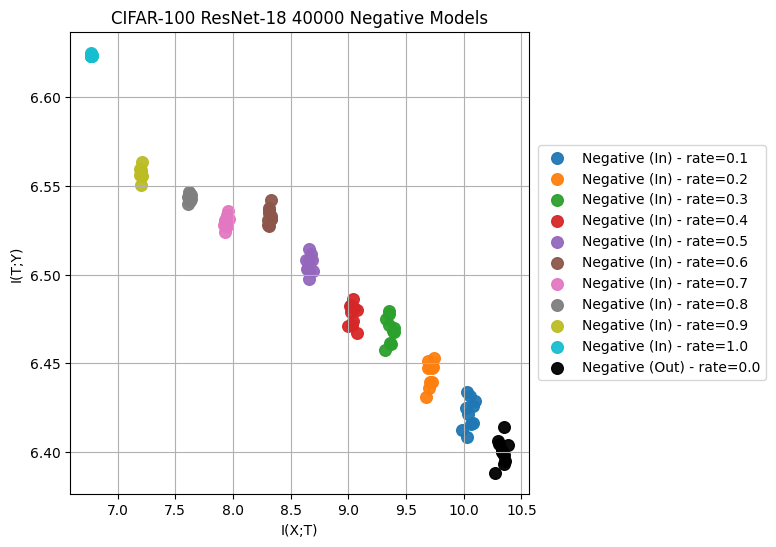

In [69]:
plot_neg_pairs("CIFAR-100", "ResNet-18", range(42, 52), 40000)

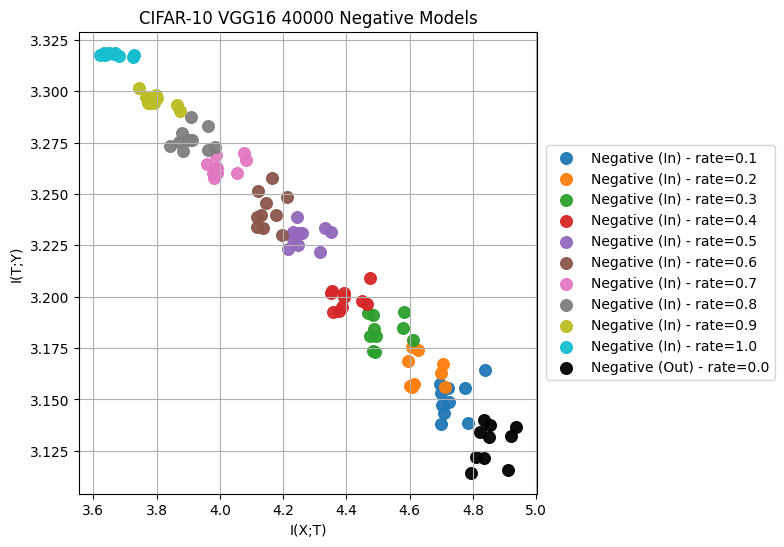

In [70]:
plot_neg_pairs("CIFAR-10", "VGG16", range(42, 52), 40000)

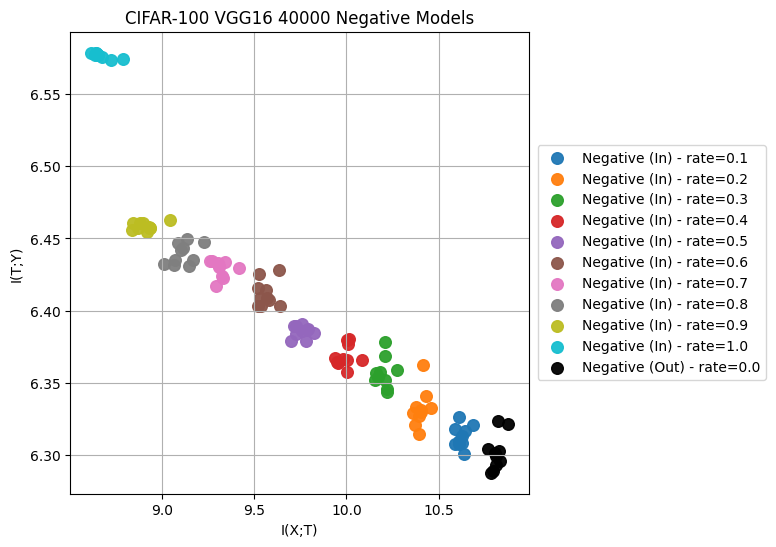

In [71]:
plot_neg_pairs("CIFAR-100", "VGG16", range(42, 52), 40000)

In [ ]:
plot_neg_pairs("CIFAR-10", "DeiT", range(42, 52), "40000_Mixup_Hard")

# Hypothesis Testing Check

In [42]:
import numpy as np
from scipy.stats import chi2

def hotelling_T2_raw_fit(aux_matrix, ddof=1):
    X = np.asarray(aux_matrix, dtype=float)
    k, p = X.shape
    mu = X.mean(axis=0)
    S = np.cov(X, rowvar=False, ddof=ddof)

    evals = np.linalg.eigvalsh(S)
    cond = float(evals.max() / max(evals.min(), 1e-12))

    info = {"mu": mu, "S": S, "eigvals": evals, "cond": cond, "k": k, "p": p}
    return mu, S, info

def hotelling_T2_raw_score(mu, S, x, k=None, scaling="none"):
    """
    scaling:
      - "none": T2 = md2
      - "paper": T2 = (k/(k+1)) * md2   (Eq.(6)-style single-sample correction)
      - "k": T2 = k * md2               (some codebases do this; not Eq.(6))
    """
    x = np.asarray(x, dtype=float).ravel()
    diff = x - mu

    Sinv = np.linalg.inv(S)
    md2 = float(diff @ Sinv @ diff)

    if scaling == "none":
        T2 = md2
    elif scaling == "paper":
        if k is None:
            raise ValueError("k must be provided for scaling='paper'")
        T2 = float((k / (k + 1.0)) * md2)
    elif scaling == "k":
        if k is None:
            raise ValueError("k must be provided for scaling='k'")
        T2 = float(k * md2)
    else:
        raise ValueError("scaling must be in {'none','paper','k'}")

    p_value = 1.0 - chi2.cdf(T2, df=len(mu))
    return T2, p_value, {"diff": diff, "md2": md2, "scaling": scaling}

def decisions_from_p(p_value, alphas=(0.10, 0.05, 0.01, 0.001)):
    """
    Reject H0 if p < alpha.
    Returns dict: {alpha: True/False}
    """
    return {a: (p_value < a) for a in alphas}

def evaluate_group(name, samples, mu, S, alphas=(0.10, 0.05, 0.01, 0.001), verbose=False, k=None, scaling="none"):
    """
    samples: iterable of 2D points like (ix,iy) or array-like shape (2,)
    Returns per-sample records and a structured summary of rejection rates.
    """
    records = []
    for idx, x in enumerate(samples):
        T2, pval, extra = hotelling_T2_raw_score(mu, S, x, k, scaling)
        dec = decisions_from_p(pval, alphas=alphas)
        rec = {"group": name, "idx": idx, "x": np.asarray(x, float), "T2": T2, "p": pval, **dec}
        records.append(rec)
        if verbose:
            print(f"[{name} #{idx}] x={rec['x']}  T2={T2:.6f}  p={pval:.6g}  " +
                  " ".join([f"a={a}:{'REJ' if rec[a] else 'OK'}" for a in alphas]))

    n = len(records)
    
    # Store counts and rates in dictionaries with the alpha floats as keys
    counts = {}
    rates = {}
    
    for a in alphas:
        rej = sum(1 for r in records if r[a])
        counts[a] = rej
        rates[a] = rej / max(n, 1)

    # Structured summary
    summary = {
        "group": name, 
        "n": n,
        "counts": counts, 
        "rates": rates
    }

    return records, summary

In [73]:
import random

def move_random_samples(data, n=1, seed=42):
    """
    Randomly move `n` samples from each source key's list to the 2.0 key.

    Args:
        data: dict mapping rates to lists of file paths
        n: number of samples to move from each key
        seed: random seed for reproducibility
    """
    rng = random.Random(seed)
    source_keys = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    target_key = 2.0
    data[target_key] = []

    for key in source_keys:
        if n > len(data[key]):
            raise ValueError(f"Key {key}: requested {n} samples but only {len(data[key])} available.")

        chosen_indices = sorted(rng.sample(range(len(data[key])), n), reverse=True)

        for idx in chosen_indices:
            chosen_value = data[key].pop(idx)
            data[target_key].append(chosen_value)

    return data

In [ ]:
neg_dict = build_neg_dict("CIFAR-10", "ResNet-18", seed_range)
print(neg_dict)

In [75]:
neg_dict = move_random_samples(neg_dict, n=3, seed=42)  # test_statistic: 77, neg_test:33



In [82]:
points = read_mi_points(neg_dict[0.5][0], "in")
print(points)

[{'path': './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_43_1.0_overlap_0.5_size_10000_MI.csv', 'epoch': 99, 'ix': 3.9239094257354736, 'iy': 3.2468724250793457}]


In [84]:
control_group = []
negative_test_group = []

for key, value in neg_dict.items():
    if key == 0.0:
        for path in value:
            points = read_mi_points(path, "out")
            control_group.append((points[0]['ix'], points[0]['iy']))
    elif key == 2.0:
        for path in value:
            points = read_mi_points(path, "in")
            negative_test_group.append((points[0]['ix'], points[0]['iy']))
    else:
        for path in value:
            points = read_mi_points(path, "in")
            control_group.append((points[0]['ix'], points[0]['iy']))
            
control_arr = np.array(control_group, dtype=float)
neg_test_arr = np.array(negative_test_group, dtype=float)

[(4.484598636627197, 3.177073240280152), (4.507013320922852, 3.166146278381348), (4.522412300109863, 3.176058053970337), (4.452061176300049, 3.167655229568481), (4.478219032287598, 3.1787919998168945)]
[(3.360804557800293, 3.319582462310791), (3.347400665283203, 3.319582462310791), (3.3457250595092773, 3.319581985473633), (4.371413707733154, 3.200135946273804), (4.414436340332031, 3.189892530441284)]
77
33


In [ ]:
alphas = (0.10, 0.05, 0.01, 0.001)
held_out_size = 10
benign_path_ls = [overlapping_model_16, same_model_16]

for i in range(10):
    print(f"The {i} time sampling run:")
    neg_pairs, aux_matrix = collecting_test_samples(benign_path_ls, held_out_size)
    mu, S, fit_info = hotelling_T2_raw_fit(aux_matrix, ddof=1)
    print("FIT:", fit_info)
    
    neg_records, neg_summary = evaluate_group("NEG(benign-heldout)", neg_pairs, mu, S, alphas=alphas, verbose=True,
                                             k=29, scaling="paper")
    print("NEG SUMMARY:", neg_summary)
    
    pos_records, pos_summary = evaluate_group("POS(suspect)", positive_arr, mu, S, alphas=alphas, verbose=True,
                                             k=29, scaling="paper")
    print("POS SUMMARY:", pos_summary)

In [87]:
for frac in np.arange(0.0, 1.1, 0.1):
    print(frac)

0.0
0.1
0.2
0.30000000000000004
0.4
0.5
0.6000000000000001
0.7000000000000001
0.8
0.9
1.0
